In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso,Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [28]:
np.random.seed(42)
df = pd.DataFrame({
    "Area": np.random.randint(800, 3000, 100),
    "Bedrooms": np.random.randint(1, 6, 100),
    "Age": np.random.randint(1, 25, 100),
})

df["Price"] = (
    df["Area"] * 100 +
    df["Bedrooms"] * 50000 -
    df["Age"] * 2000 +
    np.random.randint(-50000, 50000, 100)
)


# Introduce some missing values
df.loc[4, "Area"] = np.nan
df.loc[2, "Bedrooms"] = np.nan
df.loc[3, "Age"] = np.nan

print(df.head())

     Area  Bedrooms  Age   Price
0  1660.0       2.0  1.0  247828
1  2094.0       2.0  8.0  262111
2  1930.0       NaN  7.0  332420
3  1895.0       5.0  NaN  450252
4     NaN       3.0  8.0  328101


In [36]:
X = df.drop("Price",axis=1)
X=df[['Area','Bedrooms','Age']]
y=df['Price']


In [37]:
print(X)

      Area  Bedrooms   Age
0   1660.0       2.0   1.0
1   2094.0       2.0   8.0
2   1930.0       NaN   7.0
3   1895.0       5.0   NaN
4      NaN       3.0   8.0
..     ...       ...   ...
95  1197.0       3.0  14.0
96  1670.0       3.0  21.0
97  1192.0       4.0   6.0
98  1006.0       4.0   3.0
99  1838.0       1.0   9.0

[100 rows x 3 columns]


In [38]:
imputer=SimpleImputer(strategy='mean')
X=pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [39]:
print(X.isnull().sum())

Area        0
Bedrooms    0
Age         0
dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

In [46]:
lasso = Lasso(alpha=1000)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

In [56]:
def evaluation_model(name,x,y):
    print(f"\n{name}")
    print(f"mean square error is {mean_squared_error(x,y):.2f}")
    print(f"MAE {mean_absolute_error(x,y):.2f}")
    print(f"R2 Score {r2_score(x,y)}")
          
evaluation_model("Lasso Regression",lasso_pred,y_test)
evaluation_model("Ridge Regression",ridge_pred,y_test)


Lasso Regression
mean square error is 1061558268.61
MAE 27755.39
R2 Score 0.8676698637340884

Ridge Regression
mean square error is 1054978616.65
MAE 27727.34
R2 Score 0.8701458118234655


In [63]:
print("Ridge Coefficients")
print(ridge.coef_)

print("\nLasso Coefficients")
print(lasso.coef_)

Ridge Coefficients
[ 61241.62826038  65416.60880903 -10960.32940701]

Lasso Coefficients
[ 60944.76502794  65161.57627706 -10032.62688226]


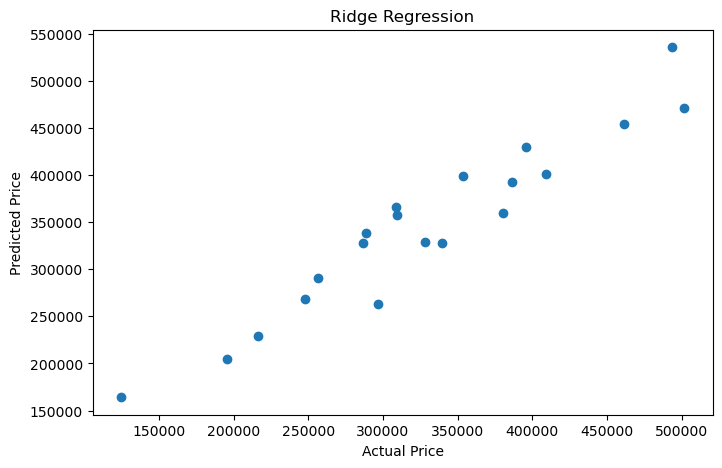

In [64]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    ridge_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression")

plt.show()